In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
data = pd.read_csv('aqi dataset.csv')
print(data.head())

   AQI Value  CO AQI Value  Ozone AQI Value  ...  PM2.5 AQI Value      lat      lng
0         51             1               36  ...               51  44.7444  44.2031
1         41             1                5  ...               41  -5.2900 -44.4900
2         41             1                5  ...               41 -11.2958 -41.9869
3         66             1               39  ...               66  37.1667  15.1833
4         34             1               34  ...               20  53.0167  20.8833

[5 rows x 7 columns]


In [5]:
data = data.dropna()
data.columns = [col.strip().lower() for col in data.columns]

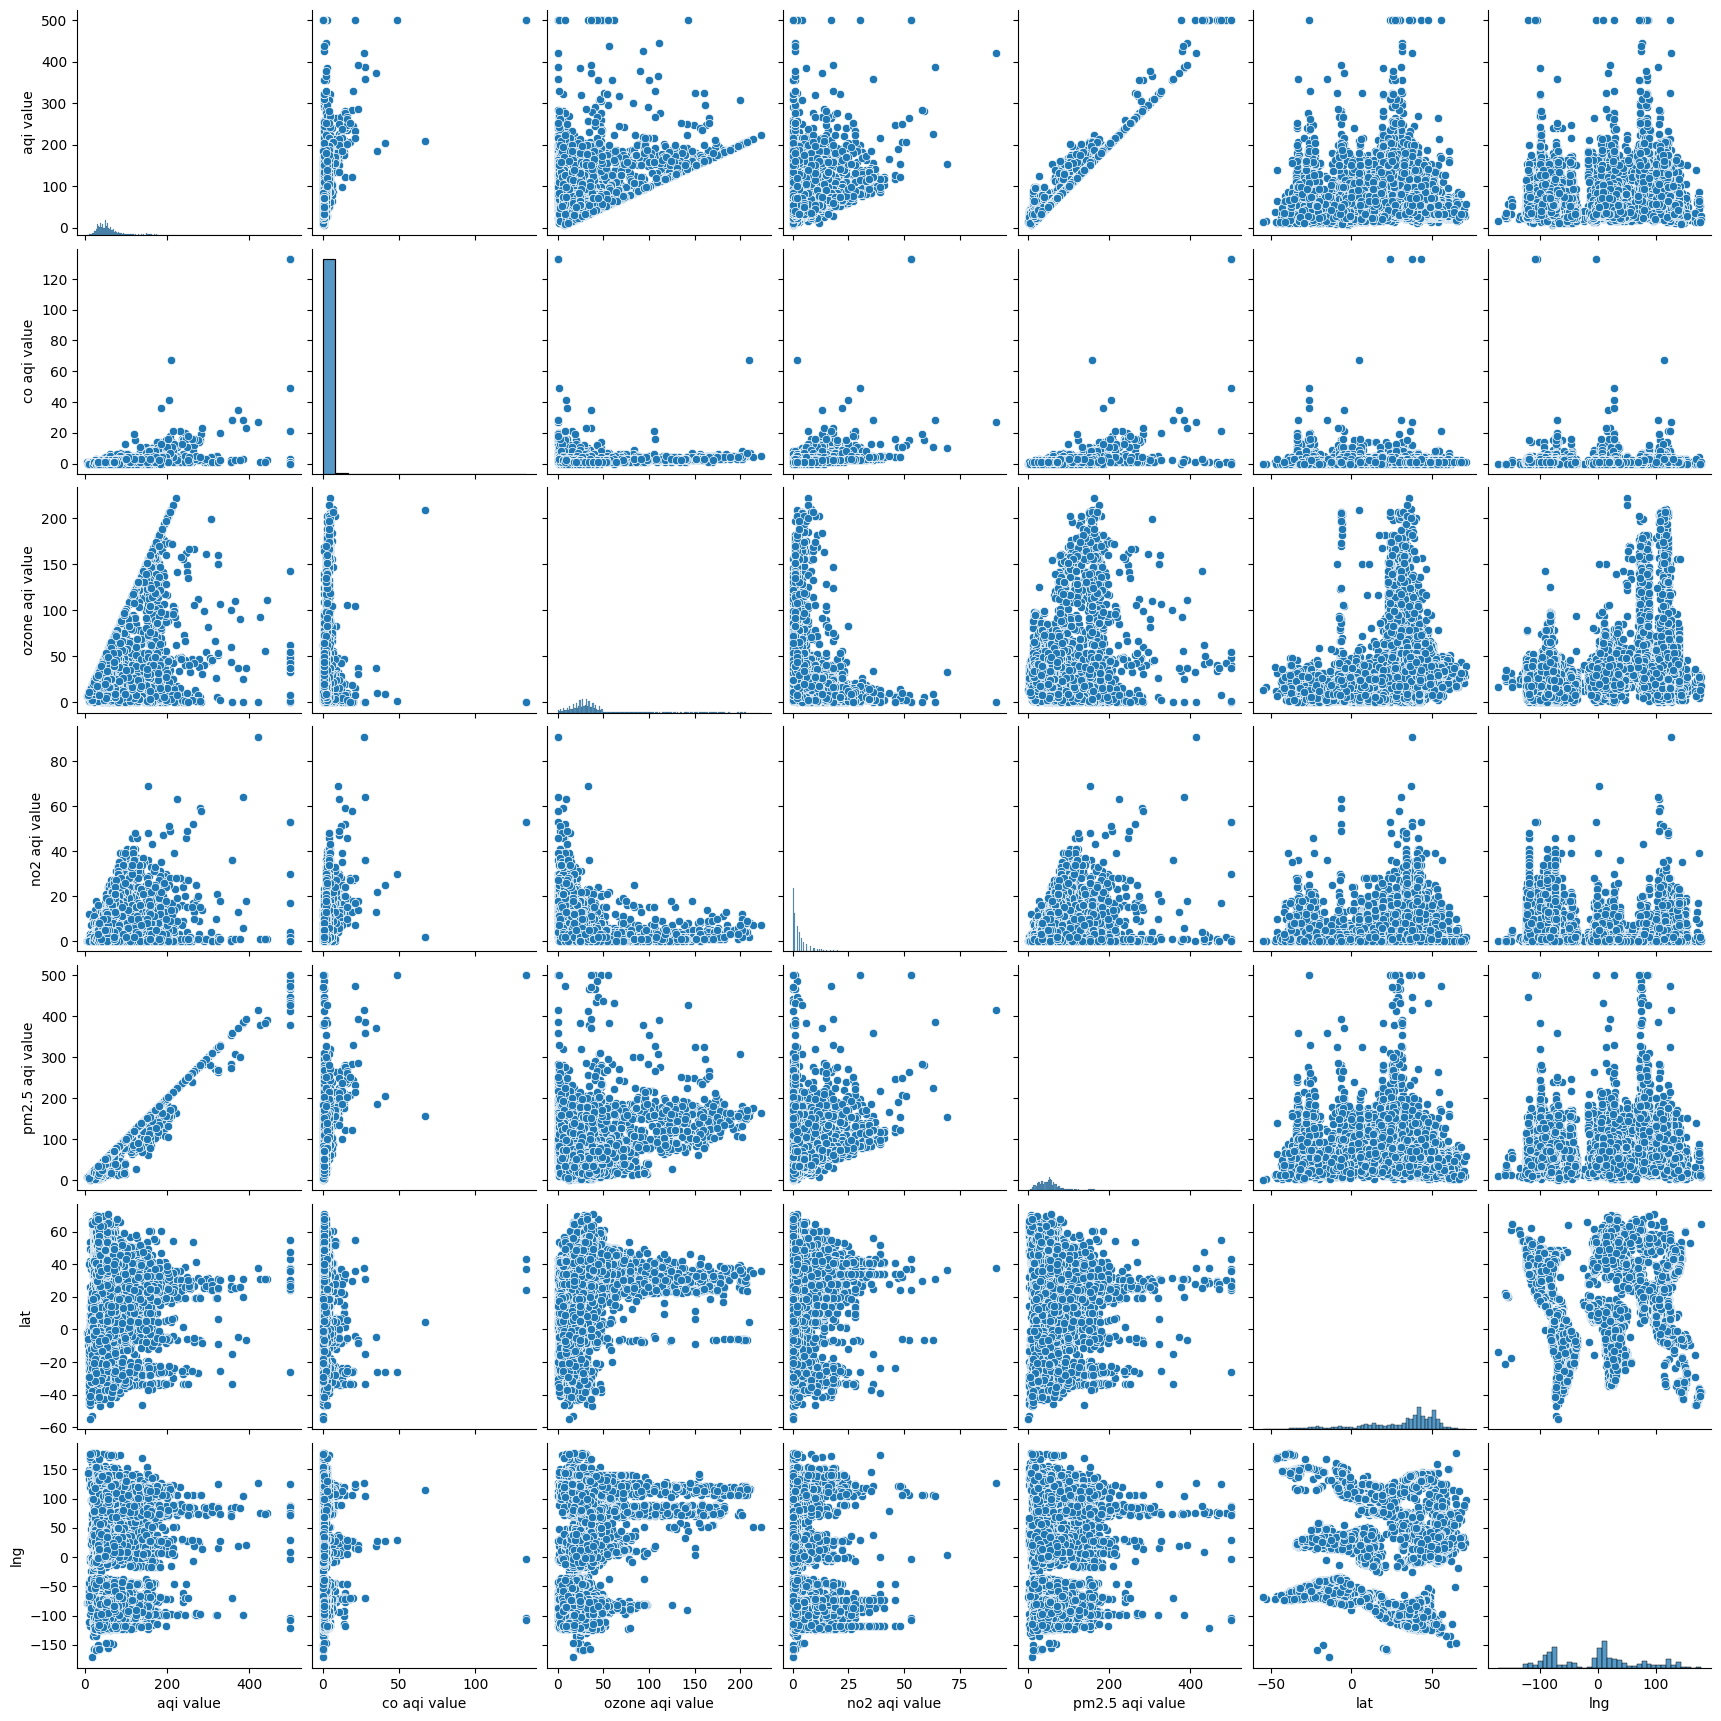

<Axes: >

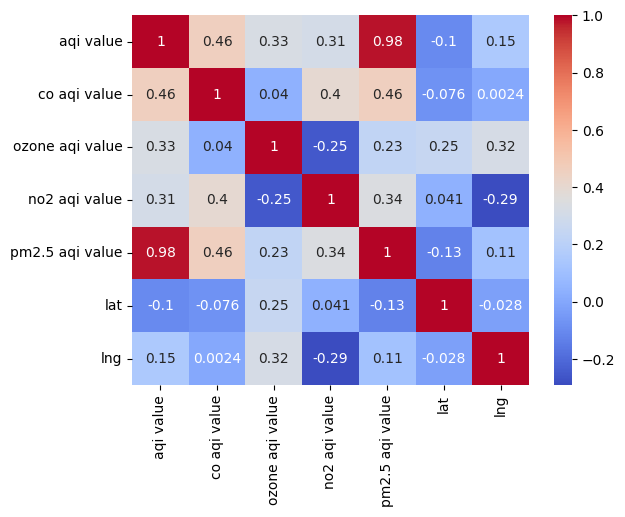

In [6]:
sns.pairplot(data)
plt.show()

corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [7]:
X = data[['co aqi value', 'ozone aqi value', 'no2 aqi value', 'pm2.5 aqi value']]
y = data['aqi value']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [10]:
y_pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 0.08944893680742742
Mean Squared Error: 2.5933745732255167
R2 Score: 0.9984363282525895


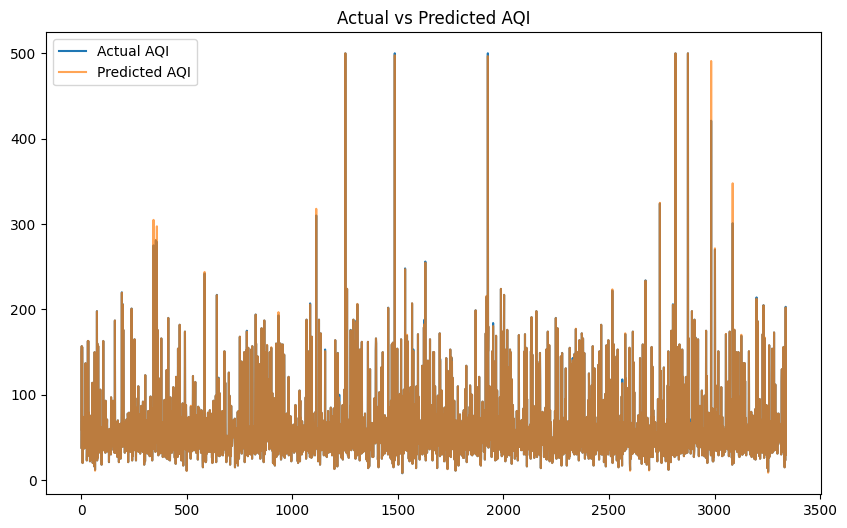

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual AQI')
plt.plot(y_pred, label='Predicted AQI', alpha=0.7)
plt.title('Actual vs Predicted AQI')
plt.legend()
plt.show()